In [9]:
#Grabbing all the things

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import numpy as np
import json
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from collections import Counter

#import synthetic data

emb_a    = np.load(r'C:\Users\Bert\Downloads\set_a_embeddings.npy')
emb_b    = np.load(r'C:\Users\Bert\Downloads\set_b_embeddings.npy')
metadata = json.loads(open(r'C:\Users\Bert\Downloads\metadata.json').read())

labels_raw = [m['domain'] for m in metadata]
le = LabelEncoder()
labels = le.fit_transform(labels_raw)

print('Classes:', le.classes_)
print(f'Set A shape: {emb_a.shape}')
print(f'Set B shape: {emb_b.shape}')
print(f'Labels: {len(labels)}')
print(Counter(labels))

#I decided last minute to remove unknown as a domain. When I ran the counter I saw it only had 7 entries
mask = labels != 6
emb_a = emb_a[mask]
emb_b = emb_b[mask]
labels = labels[mask]

print(Counter(labels))
print(f'After filtering - Set A: {emb_a.shape}, Set B: {emb_b.shape}, Labels: {len(labels)}')


Classes: ['creative' 'education' 'finance' 'healthcare' 'operations' 'technical'
 'unknown']
Set A shape: (1600, 768)
Set B shape: (1600, 768)
Labels: 1600
Counter({3: 267, 1: 267, 2: 266, 0: 266, 4: 264, 5: 263, 6: 7})
Counter({3: 267, 1: 267, 2: 266, 0: 266, 4: 264, 5: 263})
After filtering - Set A: (1593, 768), Set B: (1593, 768), Labels: 1593


In [12]:
#Question Set A
#70/15/15 stratified split
X_train, X_tmp, y_train, y_tmp = train_test_split(
    emb_a, labels, test_size=0.30, stratify=labels, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=42)
print(f'Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}')

num_classes = len(np.unique(labels))

#MLP adapted from M11
model_a = models.Sequential([
    layers.Input(shape=(768,)),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(256, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])
model_a.compile(optimizer='adam',
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])
model_a.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_a = model_a.fit(X_train, y_train,
                        epochs=100,
                        batch_size=128,
                        validation_data=(X_val, y_val),
                        callbacks=[early_stop],
                        verbose=1)

test_loss, test_acc = model_a.evaluate(X_test, y_test, verbose=0)
print(f'\nSet A Test Accuracy: {test_acc:.4f}')

Train: 1115 | Val: 239 | Test: 239
Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_6 (Dense)             (None, 512)               393728    
                                                                 
 dropout_2 (Dropout)         (None, 512)               0         
                                                                 
 dense_7 (Dense)             (None, 256)               131328    
                                                                 
 dense_8 (Dense)             (None, 6)                 1542      
                                                                 
Total params: 526598 (2.01 MB)
Trainable params: 526598 (2.01 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/100


9/9 [==============================] - 1s 25ms/step - loss: 1.6824 - accuracy: 0.5803 - val_loss: 1.4

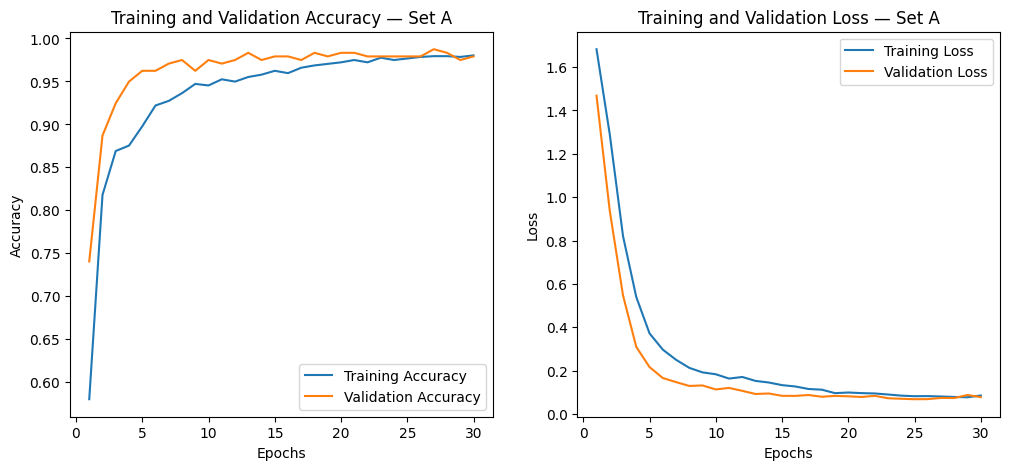

8/8 [==============================] - 0s 2ms/step


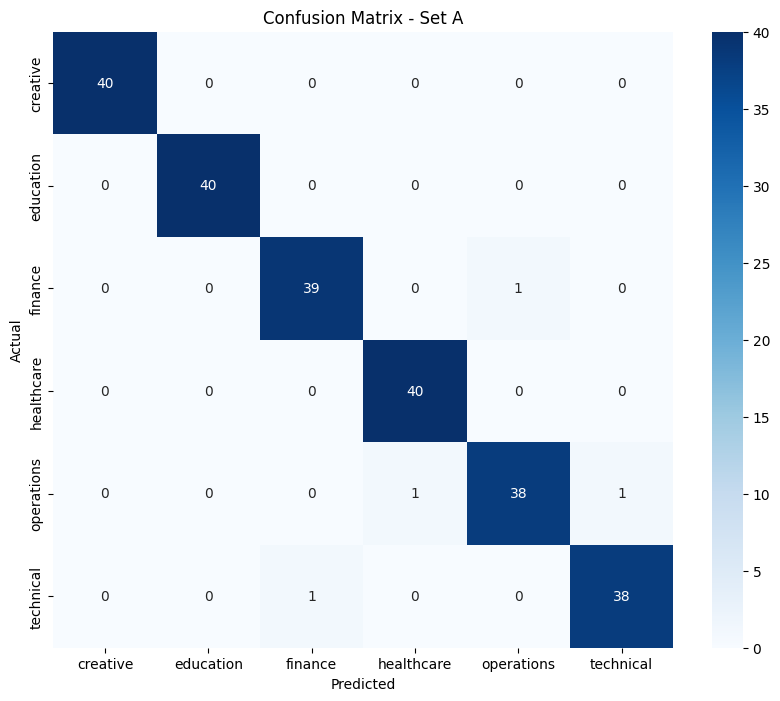

              precision    recall  f1-score   support

    creative       1.00      1.00      1.00        40
   education       1.00      1.00      1.00        40
     finance       0.97      0.97      0.97        40
  healthcare       0.98      1.00      0.99        40
  operations       0.97      0.95      0.96        40
   technical       0.97      0.97      0.97        39

    accuracy                           0.98       239
   macro avg       0.98      0.98      0.98       239
weighted avg       0.98      0.98      0.98       239



In [20]:
def plot_history(history, title='Set A'):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title(f'Training and Validation Accuracy — {title}')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title(f'Training and Validation Loss — {title}')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

plot_history(history_a, 'Set A')

class_names = [c for c in le.classes_ if c != 'unknown']
y_pred_a = np.argmax(model_a.predict(X_test), axis=1)
cm_a = confusion_matrix(y_test, y_pred_a)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_a, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Set A')
plt.show()

print(classification_report(y_test, y_pred_a, target_names=class_names))

In [26]:
#70/15/15 stratified split for Set B (same seed = same personas in each fold)
Xb_train, Xb_tmp, yb_train, yb_tmp = train_test_split(
    emb_b, labels, test_size=0.30, stratify=labels, random_state=42)
Xb_val, Xb_test, yb_val, yb_test = train_test_split(
    Xb_tmp, yb_tmp, test_size=0.50, stratify=yb_tmp, random_state=42)
print(f'Train: {len(Xb_train)} | Val: {len(Xb_val)} | Test: {len(Xb_test)}')

#MLP adapted from M11 (identical to model_a)
model_b = models.Sequential([
    layers.Input(shape=(768,)),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(256, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])
model_b.compile(optimizer='adam',
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])
model_b.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history_b = model_b.fit(Xb_train, yb_train,
                        epochs=100,
                        batch_size=128,
                        validation_data=(Xb_val, yb_val),
                        callbacks=[early_stop],
                        verbose=1)
test_loss_b, test_acc_b = model_b.evaluate(Xb_test, yb_test, verbose=0)
print(f'\nSet B Test Accuracy: {test_acc_b:.4f}')

Train: 1115 | Val: 239 | Test: 239
Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_12 (Dense)            (None, 512)               393728    
                                                                 
 dropout_4 (Dropout)         (None, 512)               0         
                                                                 
 dense_13 (Dense)            (None, 256)               131328    
                                                                 
 dense_14 (Dense)            (None, 6)                 1542      
                                                                 
Total params: 526598 (2.01 MB)
Trainable params: 526598 (2.01 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/100
9/9 [==============================] - 0s 18ms/step - loss: 1.6512 - accuracy: 0.5910 - val_loss: 1.360

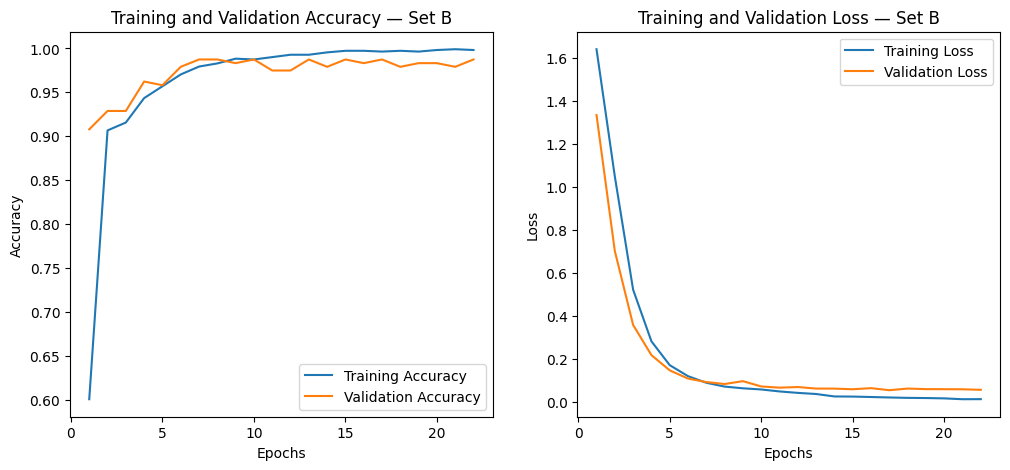

In [17]:
plot_history(history_b, 'Set B')

8/8 [==============================] - 0s 1ms/step


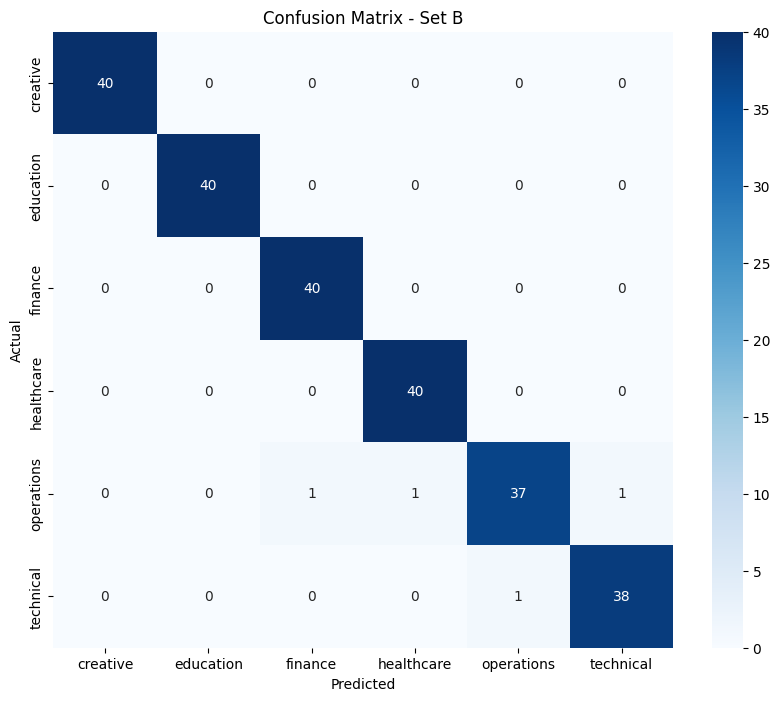

              precision    recall  f1-score   support

    creative       1.00      1.00      1.00        40
   education       1.00      1.00      1.00        40
     finance       0.98      1.00      0.99        40
  healthcare       0.98      1.00      0.99        40
  operations       0.97      0.93      0.95        40
   technical       0.97      0.97      0.97        39

    accuracy                           0.98       239
   macro avg       0.98      0.98      0.98       239
weighted avg       0.98      0.98      0.98       239



In [27]:
y_pred_b = np.argmax(model_b.predict(Xb_test), axis=1)
cm_b = confusion_matrix(yb_test, y_pred_b)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_b, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Set B')
plt.show()
print(classification_report(yb_test, y_pred_b, target_names=class_names))

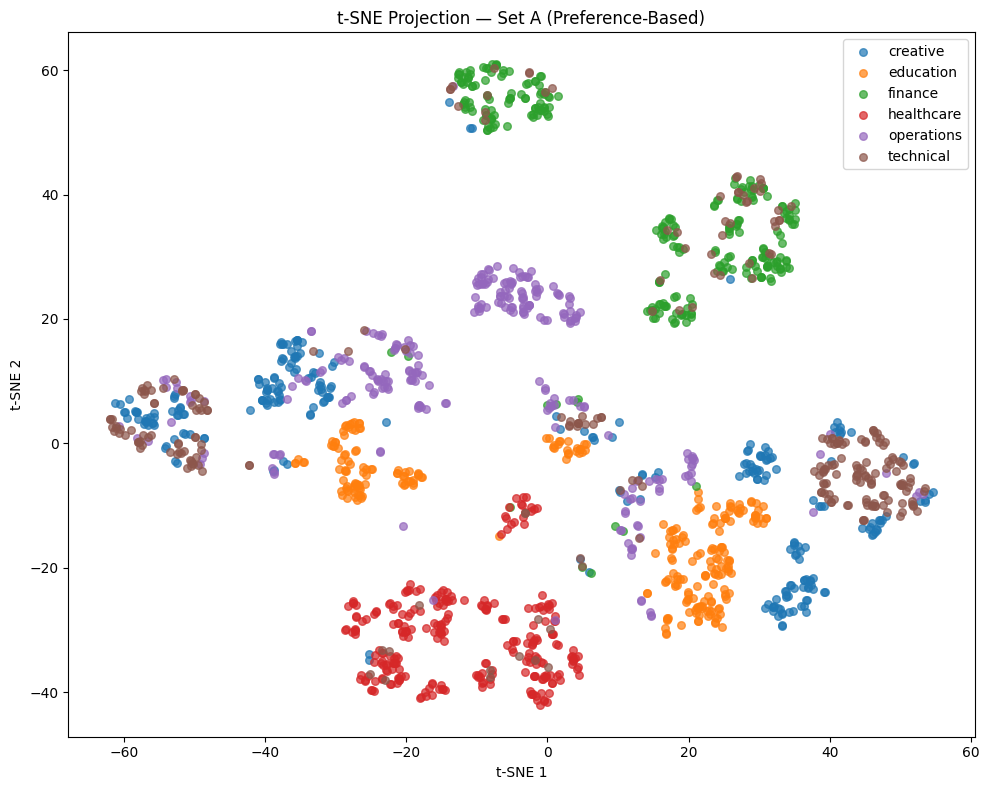

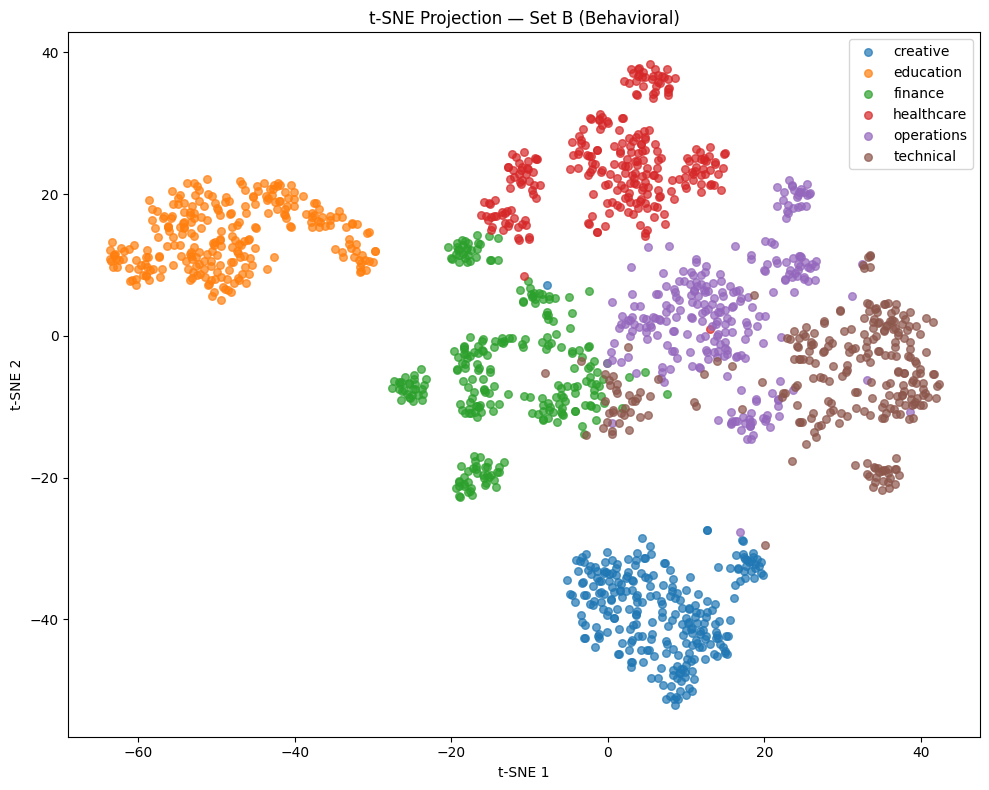

In [28]:
from sklearn.manifold import TSNE

def plot_embeddings_2d(emb, labels, class_names, title):
    tsne = TSNE(n_components=2, random_state=42, perplexity=30, init='pca')
    emb_2d = tsne.fit_transform(emb)

    plt.figure(figsize=(10, 8))
    for class_idx, name in enumerate(class_names):
        mask = labels == class_idx
        plt.scatter(emb_2d[mask, 0], emb_2d[mask, 1],
                    label=name, alpha=0.7, s=30)
    plt.title(f't-SNE Projection — {title}')
    plt.xlabel('t-SNE 1')
    plt.ylabel('t-SNE 2')
    plt.legend(loc='best', frameon=True)
    plt.tight_layout()
    plt.show()

plot_embeddings_2d(emb_a, labels, class_names, 'Set A (Preference-Based)')
plot_embeddings_2d(emb_b, labels, class_names, 'Set B (Behavioral)')

LLMs: ['gemma4:latest' 'gpt-4o-mini' 'llama3.2' 'qwen2.5:14b']


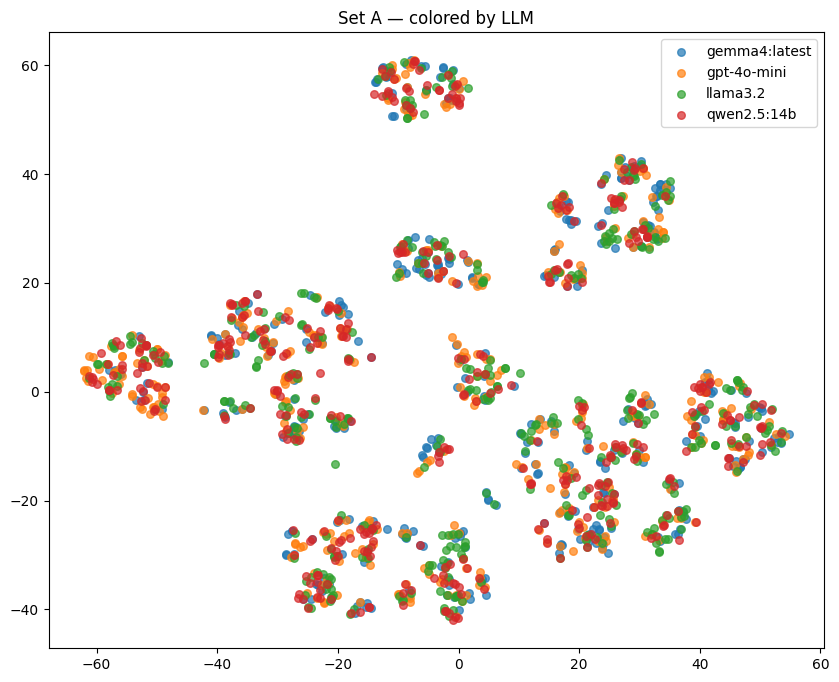

In [29]:
#This was not mine at all here in this block
#I was confused by set A clusters and asked an LLM
#what was going on here, and it suggested to run this
#thinking maybe the model that produced the response
#was creating the sub clusters. It wasn't, the colors are
#evenly mixed within every cluster, so I think it is coming from another
#question in the set beyond worker domain?

llm_labels = [m.get('llm', m.get('model', 'unknown')) for m in metadata]
llm_labels = np.array(llm_labels)[mask]  # apply same filter you used on labels

unique_llms = np.unique(llm_labels)
print(f'LLMs: {unique_llms}')

# Re-plot Set A colored by LLM instead of domain
tsne = TSNE(n_components=2, random_state=42, perplexity=30, init='pca')
emb_a_2d = tsne.fit_transform(emb_a)

plt.figure(figsize=(10, 8))
for llm in unique_llms:
    m = llm_labels == llm
    plt.scatter(emb_a_2d[m, 0], emb_a_2d[m, 1], label=llm, alpha=0.7, s=30)
plt.title('Set A — colored by LLM')
plt.legend()
plt.show()